In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.special import expit

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, EditedNearestNeighbours
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

In [2]:
def load_bank_marketing_full_from_uci_http():
    url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'
    content = urlopen(url, timeout=60).read()
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        with zf.open('bank-full.csv') as f:
            df = pd.read_csv(f, sep=';')
    return df

bank_df = load_bank_marketing_full_from_uci_http()
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
bank_df.shape, bank_df['y'].value_counts(normalize=True).mul(100).round(2)

((45211, 17),
 y
 no     88.3
 yes    11.7
 Name: proportion, dtype: float64)

- Klasa pozytywna (`y = yes`) jest mniejszosciowa (~11-12%).
- To uzasadnia analize metod dla klasyfikacji niezbalansowanej.

In [4]:
X_raw = bank_df[['balance', 'duration', 'education']].copy()
y_raw = bank_df['y'].copy()

idx = X_raw.dropna().index
X_raw = X_raw.loc[idx]
y_raw = y_raw.loc[idx]

y = (y_raw == 'yes').astype(int).to_numpy()
X = pd.get_dummies(X_raw, columns=['education'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('train positive rate:', y_train.mean().round(4))
print('test positive rate :', y_test.mean().round(4))

def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'AUPRC_prob': average_precision_score(y_true, y_score),
        'AUPRC_binary': average_precision_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_score),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Balanced_Acc': balanced_accuracy_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }

def tune_and_evaluate(name, pipeline, param_grid, X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    grid.fit(X_train, y_train)
    best_est = grid.best_estimator_
    y_score = best_est.predict_proba(X_test)[:, 1]
    test_metrics = compute_metrics(y_test, y_score, threshold=0.5)

    row = {
        'Model': name,
        'CV_AUPRC': grid.best_score_,
        **test_metrics,
        'Best_Params': grid.best_params_,
    }
    return row, best_est, y_score

X_train shape: (36168, 5)
X_test shape : (9043, 5)
train positive rate: 0.117
test positive rate : 0.117


In [5]:
results = []
best_estimators = {}
scores_on_test = {}

baseline_specs = [
    (
        'LR baseline',
        SkPipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'clf__C': [0.3, 1.0, 3.0],
            'clf__penalty': ['l1', 'l2'],
        },
    ),
    (
        'LR class_weight',
        SkPipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'clf__C': [0.3, 1.0, 3.0],
            'clf__penalty': ['l1', 'l2'],
            'clf__class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 4}],
        },
    ),
]

for name, pipe, grid in baseline_specs:
    row, est, y_score = tune_and_evaluate(name, pipe, grid, X_train, y_train, X_test, y_test)
    results.append(row)
    best_estimators[name] = est
    scores_on_test[name] = y_score

pd.DataFrame(results)[['Model', 'CV_AUPRC', 'AUPRC_prob', 'ROC_AUC', 'F1', 'Precision', 'Recall', 'MCC']]

,Model,CV_AUPRC,AUPRC_prob,ROC_AUC,F1,Precision,Recall,MCC
0,LR baseline,0.397745,0.379191,0.814115,0.235382,0.568841,0.148393,0.249431
1,LR class_weight,0.397776,0.379291,0.814450,0.356015,0.498299,0.276938,0.312848


- W tym uruchomieniu `class_weight` podniosl recall (0.148 -> 0.277) kosztem precision (0.569 -> 0.498).
- AUPRC_prob zmienil sie minimalnie (0.37919 -> 0.37929), wiec zysk dotyczy glownie punktu pracy modelu.

Porownuje: losowy, ClusterCentroids, EditedNN.

In [6]:
undersampling_specs = [
    (
        'LR + RandomUnderSampler',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35, 0.50],
            'clf__C': [0.3, 1.0, 3.0],
        },
    ),
    (
        'LR + ClusterCentroids',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', ClusterCentroids(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35, 0.50],
            'clf__C': [0.3, 1.0, 3.0],
        },
    ),
    (
        'LR + EditedNN',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', EditedNearestNeighbours()),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__n_neighbors': [3, 5, 7],
            'sampler__kind_sel': ['all', 'mode'],
            'clf__C': [0.3, 1.0],
        },
    ),
]

for name, pipe, grid in undersampling_specs:
    row, est, y_score = tune_and_evaluate(name, pipe, grid, X_train, y_train, X_test, y_test)
    results.append(row)
    best_estimators[name] = est
    scores_on_test[name] = y_score

under_df = pd.DataFrame(results)
under_df[under_df['Model'].str.contains('UnderSampler|ClusterCentroids|EditedNN')][['Model', 'CV_AUPRC', 'AUPRC_prob', 'F1', 'Precision', 'Recall', 'MCC']].sort_values('AUPRC_prob', ascending=False)

,Model,CV_AUPRC,AUPRC_prob,F1,Precision,Recall,MCC
4,LR + EditedNN,0.398741,0.380702,0.428278,0.378909,0.492439,0.345063
2,LR + RandomUnderSampler,0.397719,0.379133,0.405579,0.468983,0.357278,0.342563
3,LR + ClusterCentroids,0.395892,0.376837,0.230885,0.557971,0.145558,0.243430


- W tej grupie najlepszy byl EditedNN (AUPRC_prob 0.38070, recall 0.492).
- Nie kazda metoda undersamplingu pomaga: ClusterCentroids mial nizszy AUPRC_prob (0.37684).

In [7]:
oversampling_specs = [
    (
        'LR + RandomOverSampler',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35, 0.50],
            'clf__C': [0.3, 1.0, 3.0],
        },
    ),
    (
        'LR + SMOTE',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', SMOTE(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35, 0.50],
            'sampler__k_neighbors': [3, 5],
            'clf__C': [0.3, 1.0],
        },
    ),
    (
        'LR + BorderlineSMOTE',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', BorderlineSMOTE(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35],
            'sampler__k_neighbors': [3, 5],
            'sampler__m_neighbors': [5, 10],
            'sampler__kind': ['borderline-1', 'borderline-2'],
            'clf__C': [0.3, 1.0],
        },
    ),
    (
        'LR + ADASYN',
        ImbPipeline([
            ('scaler', StandardScaler()),
            ('sampler', ADASYN(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(max_iter=3000, solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        {
            'sampler__sampling_strategy': [0.20, 0.35, 0.50],
            'sampler__n_neighbors': [3, 5],
            'clf__C': [0.3, 1.0],
        },
    ),
]

for name, pipe, grid in oversampling_specs:
    row, est, y_score = tune_and_evaluate(name, pipe, grid, X_train, y_train, X_test, y_test)
    results.append(row)
    best_estimators[name] = est
    scores_on_test[name] = y_score

over_df = pd.DataFrame(results)
over_df[over_df['Model'].str.contains('OverSampler|SMOTE|ADASYN')][['Model', 'CV_AUPRC', 'AUPRC_prob', 'F1', 'Precision', 'Recall', 'MCC']].sort_values('AUPRC_prob', ascending=False)

,Model,CV_AUPRC,AUPRC_prob,F1,Precision,Recall,MCC
6,LR + SMOTE,0.397870,0.379194,0.430485,0.420958,0.440454,0.353202
5,LR + RandomOverSampler,0.397607,0.379120,0.293999,0.512941,0.206049,0.273563
8,LR + ADASYN,0.397623,0.378986,0.407725,0.471464,0.359168,0.344978
7,LR + BorderlineSMOTE,0.397558,0.378541,0.304927,0.515766,0.216446,0.281917


- W tym uruchomieniu najlepszy oversampling dal SMOTE (AUPRC_prob 0.37919, F1 0.430).
- ADASYN i BorderlineSMOTE nie byly tutaj lepsze ogolnie; roznice miedzy metodami sa male.

In [8]:
base_lr = best_estimators['LR baseline']

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

base_lr_for_thr = clone(base_lr)
base_lr_for_thr.fit(X_fit, y_fit)
val_scores = base_lr_for_thr.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
threshold_rows = []
for thr in thresholds:
    y_val_pred = (val_scores >= thr).astype(int)
    threshold_rows.append(
        {
            'threshold': thr,
            'AUPRC_binary': average_precision_score(y_val, y_val_pred),
            'F1': f1_score(y_val, y_val_pred, zero_division=0),
            'Precision': precision_score(y_val, y_val_pred, zero_division=0),
            'Recall': recall_score(y_val, y_val_pred, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows).sort_values(['AUPRC_binary', 'F1'], ascending=False)
best_threshold = float(threshold_df.iloc[0]['threshold'])

base_lr_refit = clone(base_lr)
base_lr_refit.fit(X_train, y_train)
base_lr_test_scores = base_lr_refit.predict_proba(X_test)[:, 1]

thr_metrics = compute_metrics(y_test, base_lr_test_scores, threshold=best_threshold)
thr_model_name = f'LR baseline + threshold={best_threshold:.2f}'

results.append(
    {
        'Model': thr_model_name,
        'CV_AUPRC': np.nan,
        **thr_metrics,
        'Best_Params': {'threshold': best_threshold},
    }
)
scores_on_test[thr_model_name] = base_lr_test_scores

threshold_df.head(10)

,threshold,AUPRC_binary,F1,Precision,Recall
21,0.26,0.246215,0.405120,0.492558,0.344045
20,0.25,0.245362,0.407186,0.480103,0.353497
22,0.27,0.243518,0.399323,0.495105,0.334594
17,0.22,0.242865,0.413065,0.440987,0.388469
19,0.24,0.242350,0.406167,0.464156,0.361059
24,0.29,0.241903,0.391127,0.511450,0.316635
16,0.21,0.241564,0.413182,0.430769,0.396975
25,0.30,0.240953,0.385944,0.521739,0.306238
23,0.28,0.240576,0.392427,0.499270,0.323251
15,0.20,0.240072,0.413859,0.415634,0.412098


- Prog 0.5 nie musi byc najlepszy przy niezbalansowanych klasach.
- Dostosowanie progu pozwala lepiej ustawic kompromis precision/recall.

In [9]:
rf_name = 'RandomForest (class_weight=balanced)'
rf_pipe = SkPipeline([
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)),
])
rf_grid = {
    'clf__n_estimators': [250, 400],
    'clf__max_depth': [None, 10],
    'clf__min_samples_leaf': [1, 4],
}

row, est, y_score = tune_and_evaluate(rf_name, rf_pipe, rf_grid, X_train, y_train, X_test, y_test)
results.append(row)
best_estimators[rf_name] = est
scores_on_test[rf_name] = y_score

pd.DataFrame([row])[['Model', 'CV_AUPRC', 'AUPRC_prob', 'ROC_AUC', 'F1', 'Precision', 'Recall', 'MCC']]

/home/user/Documents/programming/python/FMLcourse/lab5/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/user/Documents/programming/python/FMLcourse/lab5/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/user/Documents/programming/python/FMLcourse/lab5/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread

,Model,CV_AUPRC,AUPRC_prob,ROC_AUC,F1,Precision,Recall,MCC
0,RandomForest (class_weight=balanced),0.395705,0.376819,0.821607,0.41309,0.28839,0.727788,0.345151


In [10]:

class FocalLossLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.25, gamma=2.0, l2=1.0, max_iter=250):
        self.alpha = alpha
        self.gamma = gamma
        self.l2 = l2
        self.max_iter = max_iter

    def _loss(self, params, X, y):
        coef = params[:-1]
        intercept = params[-1]
        z = X @ coef + intercept
        p = expit(z)
        eps = 1e-12
        p = np.clip(p, eps, 1 - eps)

        pt = np.where(y == 1, p, 1 - p)
        alpha_t = np.where(y == 1, self.alpha, 1 - self.alpha)

        focal = -alpha_t * ((1 - pt) ** self.gamma) * np.log(pt)
        reg = 0.5 * self.l2 * np.sum(coef ** 2)
        return float(np.mean(focal) + reg)

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        y = y.astype(int)

        x0 = np.zeros(X.shape[1] + 1)
        opt = minimize(
            self._loss,
            x0,
            args=(X, y),
            method='L-BFGS-B',
            options={'maxiter': self.max_iter},
        )
        if not opt.success:
            raise RuntimeError(f'Focal loss optimization failed: {opt.message}')

        self.coef_ = opt.x[:-1].reshape(1, -1)
        self.intercept_ = np.array([opt.x[-1]])
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        return self

    def decision_function(self, X):
        check_is_fitted(self, ['coef_', 'intercept_'])
        X = check_array(X)
        return X @ self.coef_.ravel() + self.intercept_[0]

    def predict_proba(self, X):
        s = self.decision_function(X)
        p1 = expit(s)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [11]:
X_foc_train, X_foc_val, y_foc_train, y_foc_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

focal_rows = []
for alpha in [0.2, 0.25, 0.4]:
    for gamma in [1.0, 2.0, 3.0]:
        for l2 in [0.1, 0.5, 1.0]:
            focal_pipe = SkPipeline([
                ('scaler', StandardScaler()),
                ('clf', FocalLossLogisticRegression(alpha=alpha, gamma=gamma, l2=l2, max_iter=300)),
            ])
            focal_pipe.fit(X_foc_train, y_foc_train)
            val_score = focal_pipe.predict_proba(X_foc_val)[:, 1]
            focal_rows.append({
                'alpha': alpha,
                'gamma': gamma,
                'l2': l2,
                'AUPRC_val': average_precision_score(y_foc_val, val_score),
            })

focal_tuning_df = pd.DataFrame(focal_rows).sort_values('AUPRC_val', ascending=False)
best_focal = focal_tuning_df.iloc[0].to_dict()

focal_best_est = SkPipeline([
    ('scaler', StandardScaler()),
    ('clf', FocalLossLogisticRegression(
        alpha=float(best_focal['alpha']),
        gamma=float(best_focal['gamma']),
        l2=float(best_focal['l2']),
        max_iter=300,
    )),
])
focal_best_est.fit(X_train, y_train)
focal_score_test = focal_best_est.predict_proba(X_test)[:, 1]

focal_name = 'FocalLossLogReg'
results.append({
    'Model': focal_name,
    'CV_AUPRC': np.nan,
    **compute_metrics(y_test, focal_score_test),
    'Best_Params': {
        'alpha': float(best_focal['alpha']),
        'gamma': float(best_focal['gamma']),
        'l2': float(best_focal['l2']),
    },
})

best_estimators[focal_name] = focal_best_est
scores_on_test[focal_name] = focal_score_test

focal_tuning_df.head(10)

,alpha,gamma,l2,AUPRC_val
18,0.40,1.0,0.1,0.384609
9,0.25,1.0,0.1,0.384525
0,0.20,1.0,0.1,0.384442
21,0.40,2.0,0.1,0.384435
3,0.20,2.0,0.1,0.384342
12,0.25,2.0,0.1,0.384318
24,0.40,3.0,0.1,0.384164
15,0.25,3.0,0.1,0.384080
6,0.20,3.0,0.1,0.384078
19,0.40,1.0,0.5,0.383718


In [12]:
results_df = pd.DataFrame(results)
cols_show = ['Model', 'CV_AUPRC', 'AUPRC_prob', 'ROC_AUC', 'F1', 'Precision', 'Recall', 'Balanced_Acc', 'MCC']
results_df_sorted = results_df.sort_values('AUPRC_prob', ascending=False).reset_index(drop=True)
results_df_sorted[cols_show]

,Model,CV_AUPRC,AUPRC_prob,ROC_AUC,F1,Precision,Recall,Balanced_Acc,MCC
0,LR + EditedNN,0.398741,0.380702,0.815559,0.428278,0.378909,0.492439,0.692744,0.345063
1,FocalLossLogReg,NaN,0.379436,0.812415,0.027599,0.517241,0.014178,0.506212,0.070631
2,LR class_weight,0.397776,0.379291,0.814450,0.356015,0.498299,0.276938,0.619997,0.312848
3,LR + SMOTE,0.397870,0.379194,0.814580,0.430485,0.420958,0.440454,0.680089,0.353202
4,LR baseline,0.397745,0.379191,0.814115,0.235382,0.568841,0.148393,0.566745,0.249431
5,LR baseline + threshold=0.26,NaN,0.379191,0.814115,0.399336,0.481333,0.341210,0.646247,0.340887
6,LR + RandomUnderSampler,0.397719,0.379133,0.814467,0.405579,0.468983,0.357278,0.651839,0.342563
7,LR + RandomOverSampler,0.397607,0.379120,0.814171,0.293999,0.512941,0.206049,0.590063,0.273563
8,LR + ADASYN,0.397623,0.378986,0.814254,0.407725,0.471464,0.359168,0.652909,0.344978
9,LR + BorderlineSMOTE,0.397558,0.378541,0.813648,0.304927,0.515766,0.216446,0.594760,0.281917


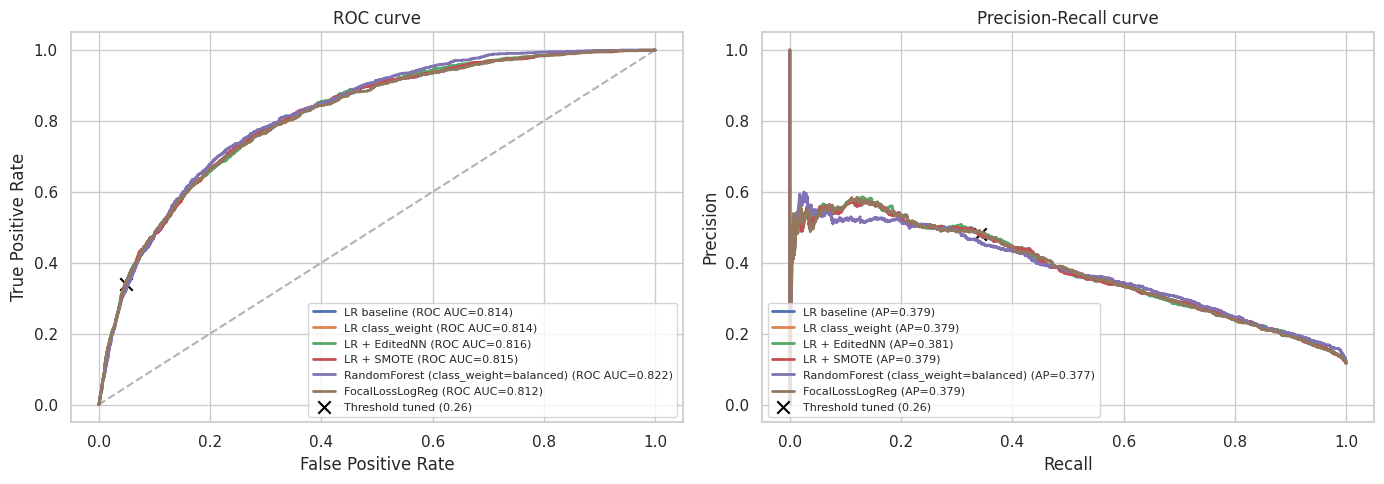

In [13]:
best_under_name = (
    results_df_sorted[results_df_sorted['Model'].str.contains('UnderSampler|ClusterCentroids|EditedNN')]
    .iloc[0]['Model']
)
best_over_name = (
    results_df_sorted[results_df_sorted['Model'].str.contains('OverSampler|SMOTE|ADASYN')]
    .iloc[0]['Model']
)

representative_models = [
    'LR baseline',
    'LR class_weight',
    best_under_name,
    best_over_name,
    'RandomForest (class_weight=balanced)',
    'FocalLossLogReg',
]
representative_models = [m for m in dict.fromkeys(representative_models) if m in scores_on_test]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in representative_models:
    score = scores_on_test[name]
    fpr, tpr, _ = roc_curve(y_test, score)
    precision, recall, _ = precision_recall_curve(y_test, score)

    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (ROC AUC={roc_auc_score(y_test, score):.3f})")
    axes[1].plot(recall, precision, lw=2, label=f"{name} (AP={average_precision_score(y_test, score):.3f})")

thr_name = [m for m in scores_on_test if m.startswith('LR baseline + threshold=')][0]
thr_val = float(thr_name.split('=')[-1])
thr_scores = scores_on_test[thr_name]
y_thr = (thr_scores >= thr_val).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_thr).ravel()
fpr_thr = fp / (fp + tn)
tpr_thr = tp / (tp + fn)
prec_thr = tp / (tp + fp) if (tp + fp) else 0.0
rec_thr = tp / (tp + fn) if (tp + fn) else 0.0

axes[0].scatter([fpr_thr], [tpr_thr], marker='x', s=80, color='black', label=f'Threshold tuned ({thr_val:.2f})')
axes[1].scatter([rec_thr], [prec_thr], marker='x', s=80, color='black', label=f'Threshold tuned ({thr_val:.2f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=8)

axes[1].set_title('Precision-Recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.show()

- **`class_weight`:** zwiekszyl recall, ale kosztem precision; poprawa AUPRC_prob byla minimalna.
- **Undersampling:** najlepszy byl EditedNN; inne warianty (np. ClusterCentroids) mogly pogorszyc AUPRC.
- **Oversampling:** w tej probie najlepiej wypadl SMOTE; ADASYN i BorderlineSMOTE nie byly wyraznie lepsze.
- **Threshold tuning:** glownie przesuwa punkt pracy precision/recall; nie poprawia AUPRC_prob predykcji probabilistycznych.
- **Random Forest:** dal bardzo wysoki recall, ale nizsza precision i AUPRC_prob niz najlepsze warianty LR.
- **Focal loss:** mial konkurencyjne AUPRC_prob, ale przy progu 0.5 bardzo niski recall/F1, wiec wymaga dalszego strojenia progu.

W zadaniach niezbalansowanych sama accuracy nie wystarcza; kluczowe sa AUPRC, recall/precision i dobor progu pod koszt bledu biznesowego. W tym notebooku roznice AUPRC miedzy wieloma metodami sa niewielkie, wiec warto interpretowac je jako lekkie przewagi, a nie duze skoki jakosci.